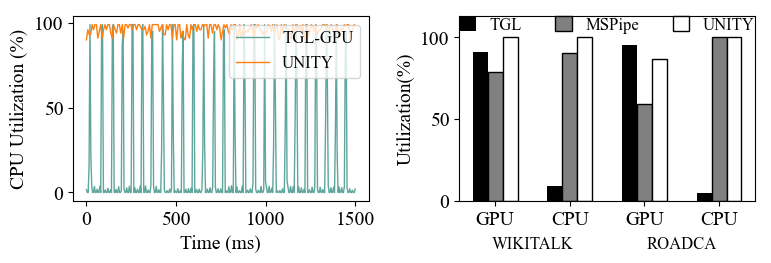

In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=14)
plt.rc('axes', titlesize=14)

# 从 YAML 文件读取数据（图1）
input_file_1 = "data1.yaml"

with open(input_file_1, "r") as file:
    data_1 = yaml.load(file, Loader=yaml.FullLoader)

# 设置时间戳的最小值和最大值
min_timestamp = 0.0  # 最小时间戳值
max_timestamp = 15.0  # 最大时间戳值

# 提取时间戳和 GPU 利用率，且只选择时间戳在给定范围内的数据
timestamps_1 = [float(item['timestamp']) for item in data_1 if min_timestamp <= float(item['timestamp']) <= max_timestamp]
gpu_usages_1 = [item['gpu_usage'] for item in data_1 if min_timestamp <= float(item['timestamp']) <= max_timestamp]

# 每隔三个数据提取一个
timestamps_1 = timestamps_1[::5]
gpu_usages_1 = gpu_usages_1[::5]

# 从 YAML 文件读取数据（图2）
input_file_2 = "gpu_uni2_modified.yaml"

with open(input_file_2, "r") as file:
    data_2 = yaml.load(file, Loader=yaml.FullLoader)

# 提取时间戳和 GPU 利用率，且只选择时间戳在给定范围内的数据
timestamps_2 = [float(item['timestamp']) for item in data_2 if min_timestamp <= float(item['timestamp']) <= max_timestamp]
gpu_usages_2 = [item['gpu_usage'] for item in data_2 if min_timestamp <= float(item['timestamp']) <= max_timestamp]

# 每隔三个数据提取一个
timestamps_2 = timestamps_2[::8]
gpu_usages_2 = gpu_usages_2[::8]


# 绘制折线图和柱状图的子图，并调整子图的大小
fig = plt.figure(figsize=(8, 3))

# 使用 gridspec 来定义子图布局
gs = fig.add_gridspec(1, 2, width_ratios=[2, 2])  # 设置第一个子图占宽度的3倍，第二个子图占1倍

# 创建折线图子图
ax1 = fig.add_subplot(gs[0])
ax1.plot(timestamps_1, gpu_usages_1, label="TGL-GPU", color='#5ea69c', linewidth=1)
ax1.plot(timestamps_2, gpu_usages_2, label="UNITY", color='#ff7f0e', linewidth=1)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("CPU Utilization (%)")
ax1.legend(loc='upper right', fontsize=12)
current_ticks = ax1.get_xticks()

# 选择中间的4个tick位置，假设你想选择的是索引为1到4的位置
selected_ticks = current_ticks[1:5]

# 定义新的标签
tick_labels = ['0', '500', '1000', '1500']  # 给这4个tick设置标签

# 设置新的tick标签
ax1.set_xticks(selected_ticks)  # 只修改选中的4个tick位置
ax1.set_xticklabels(tick_labels)  # 修改tick标签为你想要的字符串
# 创建柱状图子图
input_file_3 = "idle.yaml"

with open(input_file_3, "r") as file:
    idle_data = yaml.load(file, Loader=yaml.FullLoader)

ax2 = fig.add_subplot(gs[1])


x_labels = ['GPU', 'CPU', 'GPU', 'CPU']
A = [91.2, 8.8, 95.4, 4.6]
B = [79.1, 90.2, 59.1, 100]
C = [100, 100, 87.1, 100]

# 设置柱状图位置
x = np.arange(len(x_labels))
width = 0.2  # 柱子的宽度



# 绘制柱状图
ax2.bar(x - width, A, width, label='TGL', color='black')
ax2.bar(x, B, width, label='MSPipe', color='gray', edgecolor='black')
ax2.bar(x + width, C, width, label='UNITY', color='white', edgecolor='black')

# 添加标签和标题
ax2.set_ylabel('Utilization(%)')
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels)
ax2.legend(ncol=3, frameon=False, fontsize=12, handlelength=1, handleheight=1,loc='upper center', bbox_to_anchor=(0.5, 1.08))
ax2.set_ylim(0, 113)

ax2.text((x[0] + x[1]) / 2, -27, 'WIKITALK', ha='center', va='center', fontsize=12)
ax2.text((x[2] + x[3]) / 2, -27, 'ROADCA', ha='center', va='center', fontsize=12)
# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig("exp6.pdf", bbox_inches='tight')

# 显示图表
plt.show()
